In [1]:
library(DESeq2)
library(dplyr)
library('Matrix')
library(tibble)
library(zoo)
library(stringr)
library(lubridate)

Loading required package: S4Vectors

Warning message:
“package ‘S4Vectors’ was built under R version 4.3.2”
Loading required package: stats4

Loading required package: BiocGenerics

Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”

Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, sort,
    table, tapply, union, unique, unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The following objects are masked from ‘package:base’:

   

ERROR: Error in library(zoo): there is no package called ‘zoo’


In [2]:
out_dir = '/home/chanj3/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/outcombined.10.06.2023/updated_analyses_adata/DEGs/'


In [3]:
ISC_module29 = c(
'AREG',
'EREG',
'DPEP1',
'ASCL2',
'GZMB',
'KRT23',
'IGF2',
'CCND1',
'CTNNBL1',
'PTPRO',
'APOLD1',
'SMOC2',
'LGR5',
'RGMB',
'HES1',
'ZFP36L2',
'SOX9',
'ZFP36L1',
'ERBB3',
'KDM5A',
'CDH1',
'REST',
'SLC11A2',
'GRB7',
'PGAP3',
'ERBB2',
'STARD3',
'MED1',
'FBXL20',
'CDK12',
'MIEN1',
'SLC38A11',
'COL2A1',
'LINC00950',
'NRN1',
'MROH8',
'CNNM1',
'RP11-25E2.1',
'RP1-23E21.2',
'NBAS',
'PIGN',
'TANGO6',
'AGER',
'LA16C-431H6.6',
'RP11-473M20.16',
'TYW5',
'FLT3LG',
'PABPN1',
'ATF2',
'CCDC27',
'FRRS1L',
'LA16C-380H5.6',
'LINC01521',
'RP4-550H1.5')

### Volcano plot for SCLC surface molecules

In [393]:
library(ggrepel)

In [394]:
library(repr)
options(repr.plot.width=12, repr.plot.height=10)
options(ggrepel.max.overlaps = Inf)


In [395]:
deg_df = read.table(paste0(out_dir, 'degs.Module29_hi_vs_lo.wilcoxon.csv'), header=T, row.names='names', sep=',')


In [396]:
deg_df

,X,scores,logfoldchanges,pvals,pvals_adj
,<int>,<dbl>,<dbl>,<dbl>,<dbl>
EEF1A1,0,30.67639,2.1764321,1.175674e-206,2.338768e-202
ASCL2,1,30.60379,4.6577870,1.089827e-205,1.083997e-201
RACK1,2,30.18734,2.2020226,3.473115e-200,2.303023e-196
HES1,3,29.50982,3.7432194,2.154173e-191,1.071324e-187
NBEAL1,4,29.33573,2.1090481,3.633440e-189,1.445600e-185
CDCA7,5,29.19825,3.5744054,2.041295e-187,6.767914e-184
OLFM4,6,28.81145,4.5510360,1.541883e-182,4.381812e-179
NACA,7,28.72347,2.0501180,1.943239e-181,4.832106e-178
EIF3E,8,28.62278,2.3469975,3.498584e-180,7.733036e-177


In [397]:
interest_genes = c('RACK1', 'NBEAL1','OLFM4','CDCA7','LEFTY1','MYC')

In [398]:
deg_df$Significant = deg_df$pvals_adj < 0.05 & abs(deg_df$logfoldchanges) > log2(1.5)
deg_df$Color = ' '
# deg_df$Color[deg_df$Significant] = 'Top'
deg_df$Color[deg_df$Significant & rownames(deg_df) %in% ISC_module29] = 'HotSpot Module 29'
deg_df$Color[deg_df$Significant & rownames(deg_df) %in% interest_genes] = 'Genes of Interest'

In [399]:
deg_df$delabel = ''
deg_df[ISC_module29, 'delabel'] = ISC_module29
deg_df[interest_genes, 'delabel'] = interest_genes


In [400]:
library(repr)
options(repr.plot.width=8, repr.plot.height=5)

In [401]:
head(deg_df)

,X,scores,logfoldchanges,pvals,pvals_adj,Significant,Color,delabel
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<lgl>,<chr>,<chr>
EEF1A1,0,30.67639,2.176432,1.175674e-206,2.338768e-202,TRUE,,
ASCL2,1,30.60379,4.657787,1.089827e-205,1.083997e-201,TRUE,HotSpot Module 29,ASCL2
RACK1,2,30.18734,2.202023,3.473115e-200,2.303023e-196,TRUE,Genes of Interest,RACK1
HES1,3,29.50982,3.743219,2.154173e-191,1.071324e-187,TRUE,HotSpot Module 29,HES1
NBEAL1,4,29.33573,2.109048,3.633440e-189,1.445600e-185,TRUE,Genes of Interest,NBEAL1
CDCA7,5,29.19825,3.574405,2.041295e-187,6.767914e-184,TRUE,Genes of Interest,CDCA7


In [53]:
table(deg_df$Color)


                 Interest ISC_Module29 
       19875            6           12 

In [426]:
deg_df = deg_df %>% dplyr::arrange(Color)

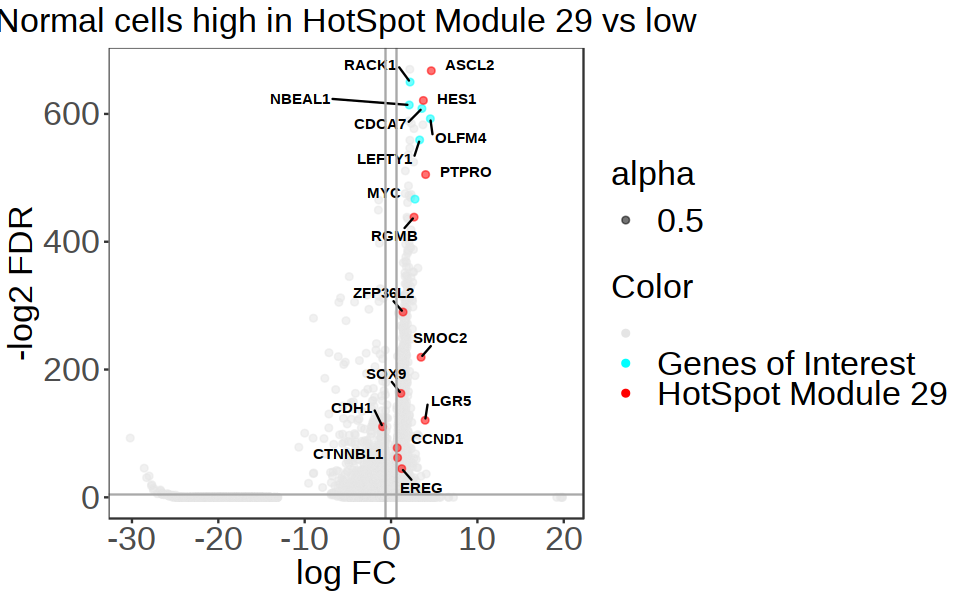

In [432]:
ggplot() +
        geom_point(data=deg_df, aes(x=logfoldchanges, y=-log2(pvals_adj), color=Color,alpha=0.5)) + 
        theme_minimal() +
        geom_text_repel(data=deg_df[deg_df$Color %in% c('HotSpot Module 29','Genes of Interest'),], aes(x=logfoldchanges, y=-log2(pvals_adj), label = delabel), 
                        color = 'black', fontface = 'bold', size=3, box.padding = 0.5, max.overlaps=Inf, force=5) +
#        geom_text_repel(data=deg_df[deg_df$Interest,], aes(x=logFC, y=-log2(adj.P.Val), label = delabel), color = 'red') +
        scale_color_manual(values=c(' ' = "gray90", 'HotSpot Module 29' = "red", 'Genes of Interest'='cyan')) +
#         scale_fill_manual(values=c(' ' = "gray90", 'HotSpot Module 29' = 'red', 'Genes of Interest'='cyan')) +
        geom_vline(xintercept=c(-log2(1.5), log2(1.5)), col="darkgray") +
        geom_hline(yintercept=-log2(0.05), col="darkgray") +
theme_bw() + xlab('log FC') + ylab('-log2 FDR') + theme(text = element_text(size=20),
                                                   plot.title = element_text(hjust = 0.5, size=20),
                                                   axis.title = element_text(size = 20),
                                                   legend.text=element_text(size=20),
                                                   axis.text = element_text(size=20),
                                                   panel.grid.minor = element_blank(),
                                                  panel.grid.major = element_blank()) +
ggtitle('Normal cells high in HotSpot Module 29 vs low')

### GSEA for limma adjusting subtype in regression

In [12]:
library(fgsea)
library(stringr)

In [41]:
gset = list()

In [42]:
for (i in c('small','large')) {
    if (i=='large')
        gmt_fn = sprintf('~/data/HTA.fresh_plasticity.SCLC.120122/ref/curated.%s.010122.gmt',i)
    else
        gmt_fn = '/home/chanj3/chanjlab/CRC_ZFP36L2.092023/ref/pathways_for_gsea.curated.small.110123.gmt'
        
    gset[[i]] = gage::readList(gmt_fn)
}



In [43]:
RunGSEA <- function(deg_df, gset0) {
  min_fdr = sort(unique(deg_df$pvals))[2]
  deg_df$pvals[deg_df$pvals==0] = min_fdr
  rnk = -log2(deg_df$pvals) * (2*(deg_df$logfoldchanges > 0) - 1)

  names(rnk) = rownames(deg_df)
  score = rnk[!is.na(rnk)] 
  
  fgseaRes <- fgsea(pathways = gset0, 
              stats = score,
              minSize=10,
              maxSize=500)#,
              #nperm=10000)
  
  fgseaRes$leadingEdge = sapply(fgseaRes$leadingEdge, function(x) str_c(x,collapse=','))
  return(fgseaRes)
  
}



In [44]:
gsea_dir = '/home/chanj3/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/outcombined.10.06.2023/updated_analyses_adata/GSEA/'
dir.create(gsea_dir)

Warning message in dir.create(gsea_dir):
“'/home/chanj3/chanjlab/CRC_ZFP36L2.092023/Patients.HTAN/outcombined.10.06.2023/updated_analyses_adata/GSEA' already exists”


In [45]:
for (mode in c('large','small')) {
    fgseaRes = RunGSEA(deg_df, gset[[mode]])

    ofile = sprintf('GSEA.normal_high_vs_low_module29.wilcoxon.%s.txt', mode)
    write.table(fgseaRes, sprintf('%s/%s',gsea_dir,ofile), sep='\t', quote=F, row.names=F)

    pval_cutoff = 0.1
    ind1 = fgseaRes$padj < pval_cutoff
    ind2 = abs(fgseaRes$NES) > 1
    ind1[is.na(ind1)] = FALSE
    ind2[is.na(ind2)] = FALSE

    write.table(fgseaRes[ind1 & ind2,], 
                sprintf('%s/%s',gsea_dir,gsub('.txt','.filtered.txt',ofile)), sep='\t', quote=F, row.names=F)
}


Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are ties in the preranked stats (20.51% of the list).
The order of those tied genes will be arbitrary, which may produce unexpected results.”
Warning message in fgseaMultilevel(...):
“There were 79 pathways for which P-values were not calculated properly due to unbalanced (positive and negative) gene-level statistic values. For such pathways pval, padj, NES, log2err are set to NA. You can try to increase the value of the argument nPermSimple (for example set it nPermSimple = 10000)”
Warning message in fgseaMultilevel(...):
“For some of the pathways the P-values were likely overestimated. For such pathways log2err is set to NA.”
Warning message in fgseaMultilevel(...):
“For some pathways, in reality P-values are less than 1e-10. You can set the `eps` argument to zero for better estimation.”
Warning message in preparePathwaysAndStats(pathways, stats, minSize, maxSize, gseaParam, :
“There are

### GSEA lollipops

In [339]:
categories_all = sort(unique(c(
'AP1','Differentiated','CRC','Inflammation','STAT','JUN/FOS','MYC','Metabolism','Metastasis','Neuronal','TERT','MAPK','Proliferation','Stemness','Stress','TGFB1','APC/WNT','Misc')))

In [340]:
length(categories_all)

[1] 18

In [341]:
paths

[1] "ASC_SMITH_CELL2018"                                   
 [2] "BENPORATH_ES_1"                                       
 [3] "BENPORATH_MYC_TARGETS_WITH_EBOX"                      
 [4] "BHATTACHARYA_EMBRYONIC_STEM_CELL"                     
 [5] "CAMP_UP.V1_UP"                                        
 [6] "CUI_TCF21_TARGETS_2_UP"                               
 [7] "DAIRKEE_TERT_TARGETS_UP"                              
 [8] "DANG_MYC_TARGETS_UP"                                  
 [9] "ES_TFS_BENPORATH"                                     
[10] "GO_CENTRAL_NERVOUS_SYSTEM_NEURON_AXONOGENESIS"        
[11] "GO_REGULATION_OF_EPITHELIAL_CELL_PROLIFERATION"       
[12] "GRADE_COLON_AND_RECTAL_CANCER_UP"                     
[13] "HALLMARK_E2F_TARGETS"                                 
[14] "HALLMARK_MYC_TARGETS_V1"                              
[15] "HALLMARK_MYC_TARGETS_V2"                              
[16] "HALLMARK_OXIDATIVE_PHOSPHORYLATION"                   
[17] "HotSpotModule_27.STRESS_"                             
[18] "HotSpotModule_29.EPI_STEM_CELLS"                      
[19] "KARLSSON_TGFB1_TARGETS_UP"                            
[20] "MILI_PSEUDOPODIA_HAPTOTAXIS_UP"                       
[21] "PAL_PRMT5_TARGETS_UP"                                 
[22] "PID_AP1_PATHWAY"                                      
[23] "PID_IL2_STAT5_PATHWAY"                                
[24] "PROVENZANI_METASTASIS_UP"                             
[25] "PUJANA_BRCA2_PCC_NETWORK"                             
[26] "PUJANA_BRCA_CENTERED_NETWORK"                         
[27] "REACTOME_METABOLISM_OF_MRNA"                          
[28] "REACTOME_METABOLISM_OF_PROTEINS"                      
[29] "REACTOME_METABOLISM_OF_RNA"                           
[30] "REACTOME_RESPIRATORY_ELECTRON_TRANSPORT"              
[31] "RICKMAN_METASTASIS_UP"                                
[32] "SANSOM_APC_TARGETS_REQUIRE_MYC"                       
[33] "SANSOM_WNT_PATHWAY_REQUIRE_MYC"                       
[34] "SCLC-P"                                               
[35] "STEIN_ESRRA_TARGETS_UP"                               
[36] "TOOKER_GEMCITABINE_RESISTANCE_UP"                     
[37] "WANG_TUMOR_INVASIVENESS_UP"                           
[38] "GO_GABAERGIC_NEURON_DIFFERENTIATION"                  
[39] "GO_NEUROTRANSMITTER_TRANSPORTER_ACTIVITY"             
[40] "HALLMARK_INTERFERON_ALPHA_RESPONSE"                   
[41] "HotSpotModule_12.SQUAMOUS"                            
[42] "HotSpotModule_20.INFLAMMATION"                        
[43] "HotSpotModule_22.ENTEROCYTES"                         
[44] "HotSpotModule_25.SQUAMOUS"                            
[45] "HotSpotModule_34.SQUAMOUS"                            
[46] "MUCINOUS"                                             
[47] "REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS"             
[48] "REACTOME_APOPTOTIC_CLEAVAGE_OF_CELL_ADHESION_PROTEINS"

In [342]:
length(categories_all)

[1] 18

In [343]:
library(pals)

In [344]:
myColors = alphabet(length(categories_all))
names(myColors) <- categories_all

In [345]:
gsea_df = read.table(paste0(gsea_dir, 'GSEA.normal_high_vs_low_module29.wilcoxon.small.filtered.txt'), sep = '\t', header=T,) %>% dplyr::arrange(-NES)



In [346]:
gsea_df = gsea_df[!duplicated(gsea_df$pathway),]

In [347]:
gsea_df = gsea_df %>% dplyr::filter(abs(NES)>1 & padj<0.05)

In [348]:
dim(gsea_df)

[1] 83  8

In [349]:
options(repr.matrix.max.rows=600, repr.matrix.max.cols=200)

In [350]:
paths = readLines(paste0(gsea_dir,'GSEA.normal_high_vs_low_module29.wilcoxon.small.interesting_pathways.txt'))

In [351]:
paths

[1] "ASC_SMITH_CELL2018"                                   
 [2] "BENPORATH_ES_1"                                       
 [3] "BENPORATH_MYC_TARGETS_WITH_EBOX"                      
 [4] "BHATTACHARYA_EMBRYONIC_STEM_CELL"                     
 [5] "CAMP_UP.V1_UP"                                        
 [6] "CUI_TCF21_TARGETS_2_UP"                               
 [7] "DAIRKEE_TERT_TARGETS_UP"                              
 [8] "DANG_MYC_TARGETS_UP"                                  
 [9] "ES_TFS_BENPORATH"                                     
[10] "GO_CENTRAL_NERVOUS_SYSTEM_NEURON_AXONOGENESIS"        
[11] "GO_REGULATION_OF_EPITHELIAL_CELL_PROLIFERATION"       
[12] "GRADE_COLON_AND_RECTAL_CANCER_UP"                     
[13] "HALLMARK_E2F_TARGETS"                                 
[14] "HALLMARK_MYC_TARGETS_V1"                              
[15] "HALLMARK_MYC_TARGETS_V2"                              
[16] "HALLMARK_OXIDATIVE_PHOSPHORYLATION"                   
[17] "HotSpotModule_27.STRESS_"                             
[18] "HotSpotModule_29.EPI_STEM_CELLS"                      
[19] "KARLSSON_TGFB1_TARGETS_UP"                            
[20] "MILI_PSEUDOPODIA_HAPTOTAXIS_UP"                       
[21] "PAL_PRMT5_TARGETS_UP"                                 
[22] "PID_AP1_PATHWAY"                                      
[23] "PID_IL2_STAT5_PATHWAY"                                
[24] "PROVENZANI_METASTASIS_UP"                             
[25] "PUJANA_BRCA_CENTERED_NETWORK"                         
[26] "REACTOME_METABOLISM_OF_MRNA"                          
[27] "REACTOME_METABOLISM_OF_PROTEINS"                      
[28] "REACTOME_METABOLISM_OF_RNA"                           
[29] "RICKMAN_METASTASIS_UP"                                
[30] "SANSOM_APC_TARGETS_REQUIRE_MYC"                       
[31] "SANSOM_WNT_PATHWAY_REQUIRE_MYC"                       
[32] "SCLC-P"                                               
[33] "STEIN_ESRRA_TARGETS_UP"                               
[34] "TOOKER_GEMCITABINE_RESISTANCE_UP"                     
[35] "WANG_TUMOR_INVASIVENESS_UP"                           
[36] "GO_GABAERGIC_NEURON_DIFFERENTIATION"                  
[37] "GO_NEUROTRANSMITTER_TRANSPORTER_ACTIVITY"             
[38] "HALLMARK_INTERFERON_ALPHA_RESPONSE"                   
[39] "HotSpotModule_12.SQUAMOUS"                            
[40] "HotSpotModule_20.INFLAMMATION"                        
[41] "HotSpotModule_22.ENTEROCYTES"                         
[42] "HotSpotModule_25.SQUAMOUS"                            
[43] "HotSpotModule_34.SQUAMOUS"                            
[44] "MUCINOUS"                                             
[45] "REACTOME_ADHERENS_JUNCTIONS_INTERACTIONS"             
[46] "REACTOME_APOPTOTIC_CLEAVAGE_OF_CELL_ADHESION_PROTEINS"

In [352]:
length(paths)

[1] 46

In [353]:
pathway_categories = data.frame(pathway = paths, category = '', row.names = paths)

In [354]:
pathway_categories$category[grepl('ASC_|ES_|STEM',pathway_categories$pathway)] = 'Stemness'
pathway_categories$category[grepl('MYC',pathway_categories$pathway)] = 'MYC'
pathway_categories$category[grepl('APOPTOSIS',pathway_categories$pathway)] = 'Apoptosis'
pathway_categories$category[grepl('PROLIFERATION',pathway_categories$pathway)] = 'Proliferation'
pathway_categories$category[grepl('AKT',pathway_categories$pathway)] = 'AKT/MTOR'
pathway_categories$category[grepl('STAT',pathway_categories$pathway)] = 'STAT'
pathway_categories$category[grepl('AXON|NEURO',pathway_categories$pathway)] = 'Neuronal'
pathway_categories$category[grepl('TGFB',pathway_categories$pathway)] = 'TGFB1'
pathway_categories$category[grepl('TERT',pathway_categories$pathway)] = 'TERT'
pathway_categories$category[grepl('IFN|INTERFERON|INFLAMM',pathway_categories$pathway)] = 'Inflammation'
pathway_categories$category[grepl('TCF|WNT|APC',pathway_categories$pathway)] = 'APC/WNT'
pathway_categories$category[grepl('E2F',pathway_categories$pathway)] = 'MAPK'
pathway_categories$category[grepl('COLON',pathway_categories$pathway)] = 'CRC'
pathway_categories$category[grepl('RESISTANCE',pathway_categories$pathway)] = 'Resistance'
pathway_categories$category[grepl('METABOLISM|OXIDATIVE_PHOSPHORYLATION|RESPIRATORY_ELECTRON',pathway_categories$pathway)] = 'Metabolism'
pathway_categories$category[grepl('AP1',pathway_categories$pathway)] = 'AP1'
pathway_categories$category[grepl('STRESS',pathway_categories$pathway)] = 'Stress'
pathway_categories$category[grepl('METASTASIS|DHESION|ADHERENS|HAPTOTAXIS|NVASIVEN',pathway_categories$pathway)] = 'Metastasis'
pathway_categories$category[grepl('SCLC-P|MUCINOUS|SQUAMOUS|BASAL|ENTEROCYTES|LEUKO',pathway_categories$pathway)] = 'Differentiated'
pathway_categories$category[grepl('BRCA|PRMT5|CAMP|ESRR',pathway_categories$pathway)] = 'Misc'


In [355]:
pathway_categories

,pathway,category
,<chr>,<chr>
ASC_SMITH_CELL2018,ASC_SMITH_CELL2018,Stemness
BENPORATH_ES_1,BENPORATH_ES_1,Stemness
BENPORATH_MYC_TARGETS_WITH_EBOX,BENPORATH_MYC_TARGETS_WITH_EBOX,MYC
BHATTACHARYA_EMBRYONIC_STEM_CELL,BHATTACHARYA_EMBRYONIC_STEM_CELL,Stemness
CAMP_UP.V1_UP,CAMP_UP.V1_UP,Misc
CUI_TCF21_TARGETS_2_UP,CUI_TCF21_TARGETS_2_UP,APC/WNT
DAIRKEE_TERT_TARGETS_UP,DAIRKEE_TERT_TARGETS_UP,TERT
DANG_MYC_TARGETS_UP,DANG_MYC_TARGETS_UP,MYC
ES_TFS_BENPORATH,ES_TFS_BENPORATH,Stemness


In [356]:
pathway_categories$category = factor(pathway_categories$category)

In [357]:
library(ggplot2)

In [358]:
plot_df = gsea_df %>% dplyr::filter(pathway %in% paths) 


In [359]:
plot_df$category = pathway_categories[plot_df$pathway, 'category']

In [360]:
plot_df = plot_df[order(plot_df$NES, plot_df$category),]

In [361]:
plot_df$Significance = -log2(plot_df$padj)

In [362]:
up_df = plot_df[plot_df$NES > 0,]

In [363]:
ord1 = (up_df %>% group_by(category) %>% summarise(max = max(NES)) %>% arrange(max))$category


In [364]:
up_df$category = factor(up_df$category, levels=ord1)

In [365]:
up_df = up_df %>% dplyr::arrange(category, NES)

In [366]:
dn_df = plot_df[plot_df$NES < 0,]

In [367]:
ord2 = (dn_df %>% group_by(category) %>% summarise(min = min(NES)) %>% arrange(min))$category


In [368]:
dn_df$category = factor(dn_df$category, levels=ord2)

In [369]:
dn_df = dn_df %>% dplyr::arrange(category, NES)

In [436]:
plot_df2 = rbind(dn_df,up_df)

In [437]:
plot_df2$pathway = factor(plot_df2$pathway, levels = plot_df2$pathway)

In [438]:
library(repr)
options(repr.plot.width=7, repr.plot.height=6.5)

In [439]:
plot_df2$category = factor(plot_df2$category, levels=sort(levels(plot_df2$category)))

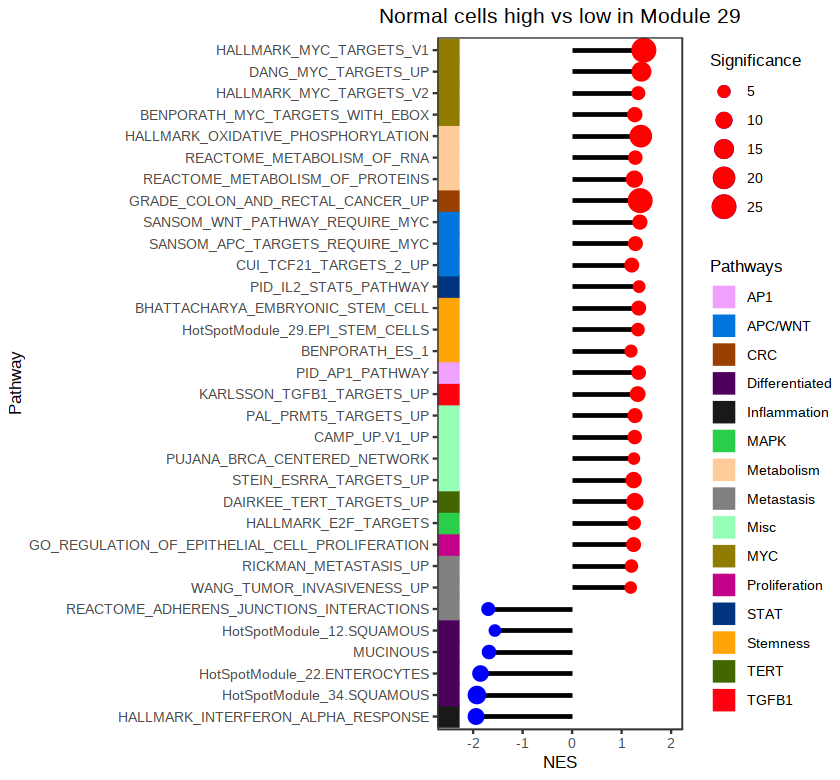

In [440]:
ggplot() + 
geom_segment(data = plot_df2, aes(x=NES, y=pathway, xend=0, yend=pathway), size=1,color='black') +
geom_point(data = plot_df2[plot_df2$NES<0,],aes(x=NES, y=pathway, size=Significance),color='blue')+
geom_point(data = plot_df2[plot_df2$NES>0,],aes(x=NES, y=pathway, size=Significance),color='red')+
scale_size_area(max_size = 6)+ #scale_color_gradient(low="blue",high="red") +
theme_bw() + xlab('NES') + ylab('Pathway') + theme(text = element_text(size=10),
                                                   plot.title = element_text(hjust = 0.5),
                                                   panel.grid.minor = element_blank(),
                                                  panel.grid.major = element_blank()) +
geom_point(data = plot_df2, aes(x=-2.5, y=pathway, color = category), shape=15, size=6) +
scale_color_manual(name = "Pathways",values = myColors[names(myColors) %in% plot_df2$category]) +
ggtitle('Normal cells high vs low in Module 29') + 
xlim(-2.5,2)

In [441]:
paths2 = paths

In [442]:
library(repr)
options(repr.plot.width=7.5, repr.plot.height=5)

In [443]:
col_label = myColors[as.character(plot_df2$category)]


Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


NULL

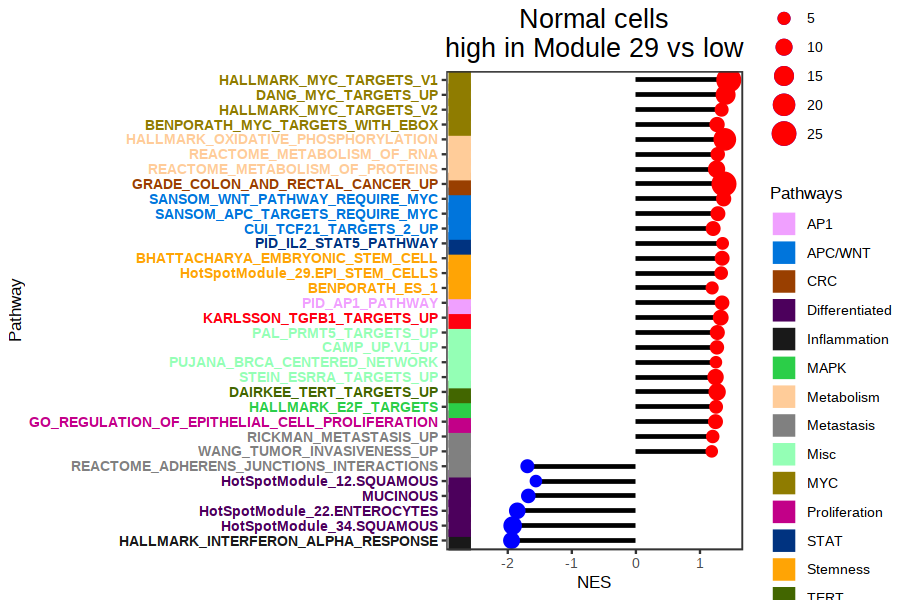

In [446]:
ggplot() + 
geom_segment(data = plot_df2, aes(x=NES, y=pathway, xend=0, yend=pathway), size=1,color='black') +
geom_point(data = plot_df2[plot_df2$NES<0,],aes(x=NES, y=pathway, size=Significance),color='blue')+
geom_point(data = plot_df2[plot_df2$NES>0,],aes(x=NES, y=pathway, size=Significance),color='red')+
scale_size_area(max_size = 6)+ #scale_color_gradient(low="blue",high="red") +
theme_bw() + xlab('NES') + ylab('Pathway') + theme(text = element_text(size=10),
                                                   plot.title = element_text(hjust = 0.5,size=16),
                                                   panel.grid.minor = element_blank(),
                                                  panel.grid.major = element_blank(),
                                                  axis.text.y = element_text(color=col_label, face='bold')) +
geom_point(data = plot_df2, aes(x=-2.75, y=pathway, color = category), shape=15, size=6) +
scale_color_manual(name = "Pathways",values = myColors[names(myColors) %in% plot_df2$category]) +
ggtitle('Normal cells\nhigh in Module 29 vs low')
guides(color=guide_legend(ncol=2)) +
xlim(-2,1.75)

In [454]:
library(repr)
options(repr.plot.width=7.5, repr.plot.height=6)

Warning message:
“Vectorized input to `element_text()` is not officially supported.
ℹ Results may be unexpected or may change in future versions of ggplot2.”


NULL

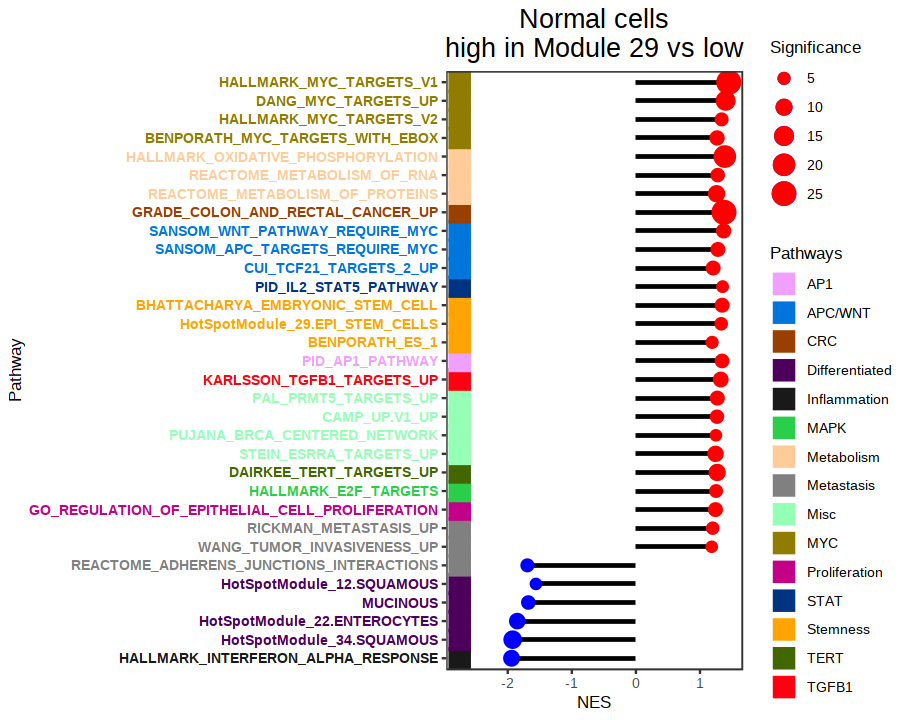

In [455]:
ggplot() + 
geom_segment(data = plot_df2, aes(x=NES, y=pathway, xend=0, yend=pathway), size=1,color='black') +
geom_point(data = plot_df2[plot_df2$NES<0,],aes(x=NES, y=pathway, size=Significance),color='blue')+
geom_point(data = plot_df2[plot_df2$NES>0,],aes(x=NES, y=pathway, size=Significance),color='red')+
scale_size_area(max_size = 6)+ #scale_color_gradient(low="blue",high="red") +
theme_bw() + xlab('NES') + ylab('Pathway') + theme(text = element_text(size=10),
                                                   plot.title = element_text(hjust = 0.5,size=16),
                                                   panel.grid.minor = element_blank(),
                                                  panel.grid.major = element_blank(),
                                                  axis.text.y = element_text(color=col_label, face='bold')) +
geom_point(data = plot_df2, aes(x=-2.75, y=pathway, color = category), shape=15, size=6) +
scale_color_manual(name = "Pathways",values = myColors[names(myColors) %in% plot_df2$category]) +
ggtitle('Normal cells\nhigh in Module 29 vs low')
guides(color=guide_legend(ncol=2)) +
xlim(-2,1.75)

### DEG Heatmap for SCLC-A

In [1323]:
degs = list()

In [1324]:
degs[['SCLC-A']] = rownames(read.table(paste0(out_dir, 'limma.transform/limma.T-SCLC-A_vs_SCLC-A.treatment_adjust.filtered.txt'), header=T, row.names=1))
degs[['SCLC-N']] = rownames(read.table(paste0(out_dir, 'limma.transform/limma.T-SCLC-N_vs_SCLC-N.treatment_adjust.filtered.txt'), header=T, row.names=1))
degs[['SCLC-P']] = read.table(paste0(out_dir, 'MAST.transform/deg.mast.transform.stratify_SCLC-P.filtered.csv'), header=T)$primerid
degs[['SCLC-Y']] = read.table(paste0(out_dir, 'MAST.transform/deg.mast.transform.stratify_SCLC-Y.filtered.csv'), header=T)$primerid

In [1325]:
deg_df = read.table(paste0(out_dir, 'limma.transform/limma.T-SCLC-A_vs_SCLC-A.treatment_adjust.filtered.txt'), header=T, row.names=1)


In [1326]:
le_genes_all = rownames(deg_df %>% dplyr::arrange('P.Value'))[1:30]

In [1327]:
subtype='A'
fn = sprintf('%s/obs.pseudobulk.T-SCLC-%s_vs_SCLC-%s.txt', out_dir, subtype, subtype)
obs_df = read.table(fn, sep = '\t', header = T, row.names=1)

obs_df$condition = as.numeric(factor(obs_df$Transformed=='True'))-1
obs_df$condition = factor(obs_df$condition)

obs_df$chemo = factor(1*(obs_df$chemo=='True'))
obs_df$IO = factor(1*(obs_df$IO=='True'))
obs_df$TKI = factor(1*(obs_df$TKI=='True'))

obs_df$LN = factor(1*(obs_df$tissue=='LN'))
obs_df$PDX = factor(1*(obs_df$tissue=='PDX'))
obs_df$metastasis = factor(1*(!obs_df$tissue %in% c('Lung','LN','PDX')))

fn = sprintf('%s/counts.pseudobulk.T-SCLC-%s_vs_SCLC-%s.genes.txt', out_dir, subtype, subtype)
g = readLines(fn)

fn = sprintf('%s/counts.pseudobulk.T-SCLC-%s_vs_SCLC-%s.samples.txt', out_dir, subtype, subtype)
bc = readLines(fn)

cts = readMM(sprintf('%s/counts.pseudobulk.T-SCLC-%s_vs_SCLC-%s.mtx', out_dir, subtype, subtype) )

cts = as.matrix(cts)

colnames(cts) = g
rownames(cts) = bc

cts = t(cts)
cts = cts[rowSums(cts) != 0,]

obs_df = obs_df[colnames(cts),]

obs_df = obs_df %>% dplyr::filter(colSums(cts) != 0)
cts = cts[,colSums(cts) != 0]

In [1328]:
tmp = rowSums(cts[,grepl('RU581_T[ab]', colnames(cts))])
cts[,'RU581_Ta'] = tmp
cts = cts[,colnames(cts) != 'RU581_Tb']

tmp = rowSums(cts[,grepl('RU581_LN[ab]', colnames(cts))])
cts[,'RU581_LNa'] = tmp
cts = cts[,colnames(cts) != 'RU581_LNb']

obs_df = obs_df[!rownames(obs_df) %in% c('RU581_Tb','RU581_LNb'),]


In [1329]:
obs_df$patient = factor(gsub('_.*','',rownames(obs_df)))
dge <- DGEList(counts=cts)
keep <- filterByExpr(dge, design)
dge <- dge[keep,,keep.lib.sizes=FALSE]
dge <- calcNormFactors(dge)

In [1330]:
logCPM <- cpm(cts, log=TRUE, prior.count = 1)

In [1331]:
scaled_df = t(scale(t(logCPM[degs[[paste0('SCLC-',subtype)]],])))

In [1332]:
scaled_df = scaled_df[,rownames(obs_df)[obs_df$SCLCtype_zscore==paste0('SCLC-',subtype)]]

In [1333]:
obs_df = obs_df[colnames(scaled_df),]

In [1334]:
obs_df$Transformed = c('de novo','Transformed')[1+(obs_df$Transformed=='True')]

In [1335]:
library(RColorBrewer)
n <- length(unique(obs_df$patient))
qual_col_pals = brewer.pal.info[brewer.pal.info$category == 'qual',]
col_vector = unlist(mapply(brewer.pal, qual_col_pals$maxcolors, rownames(qual_col_pals)))
col_patient=sample(col_vector, n)

In [1336]:
obs_df$chemo = c('Naive','Treated')[as.numeric(obs_df$chemo)]
obs_df$IO = c('Naive','Treated')[as.numeric(obs_df$IO)]
obs_df$TKI = c('Naive','Treated')[as.numeric(obs_df$TKI)]

In [1337]:
library("RColorBrewer")
library(wesanderson)
library(pals)
library(foreach)
library(circlize)

#col_patient = alphabet2(length(unique(obs_df$patient)))
names(col_patient) = sort(unique(obs_df$patient))

col_transformed = c('gray', 'darkorchid1')
names(col_transformed) = c('de novo', 'Transformed')

col_chemo = c('ghostwhite', 'navyblue')
names(col_chemo) = c('Naive', 'Treated')

col_IO = c('ghostwhite', 'navyblue')
names(col_IO) = c('Naive', 'Treated')

col_TKI = c('ghostwhite', 'navyblue')
names(col_TKI) = c('Naive', 'Treated')

col_list = list()
col_list[['Patient']] = col_patient
col_list[['Transformed']] = col_transformed
col_list[['Chemo_ever']] = col_chemo
col_list[['IO_ever']] = col_IO
col_list[['TKI_ever']] = col_TKI


In [1338]:
df2 = data.frame(Patient = obs_df$patient,
                Transformed = obs_df$Transformed,
                Chemo_ever = obs_df$chemo, IO_ever = obs_df$IO, TKI_ever = obs_df$TKI)
rownames(df2) = colnames(scaled_df)


In [1339]:
library(ComplexHeatmap)

In [1342]:
library(repr)
options(repr.plot.width=16, repr.plot.height=16)

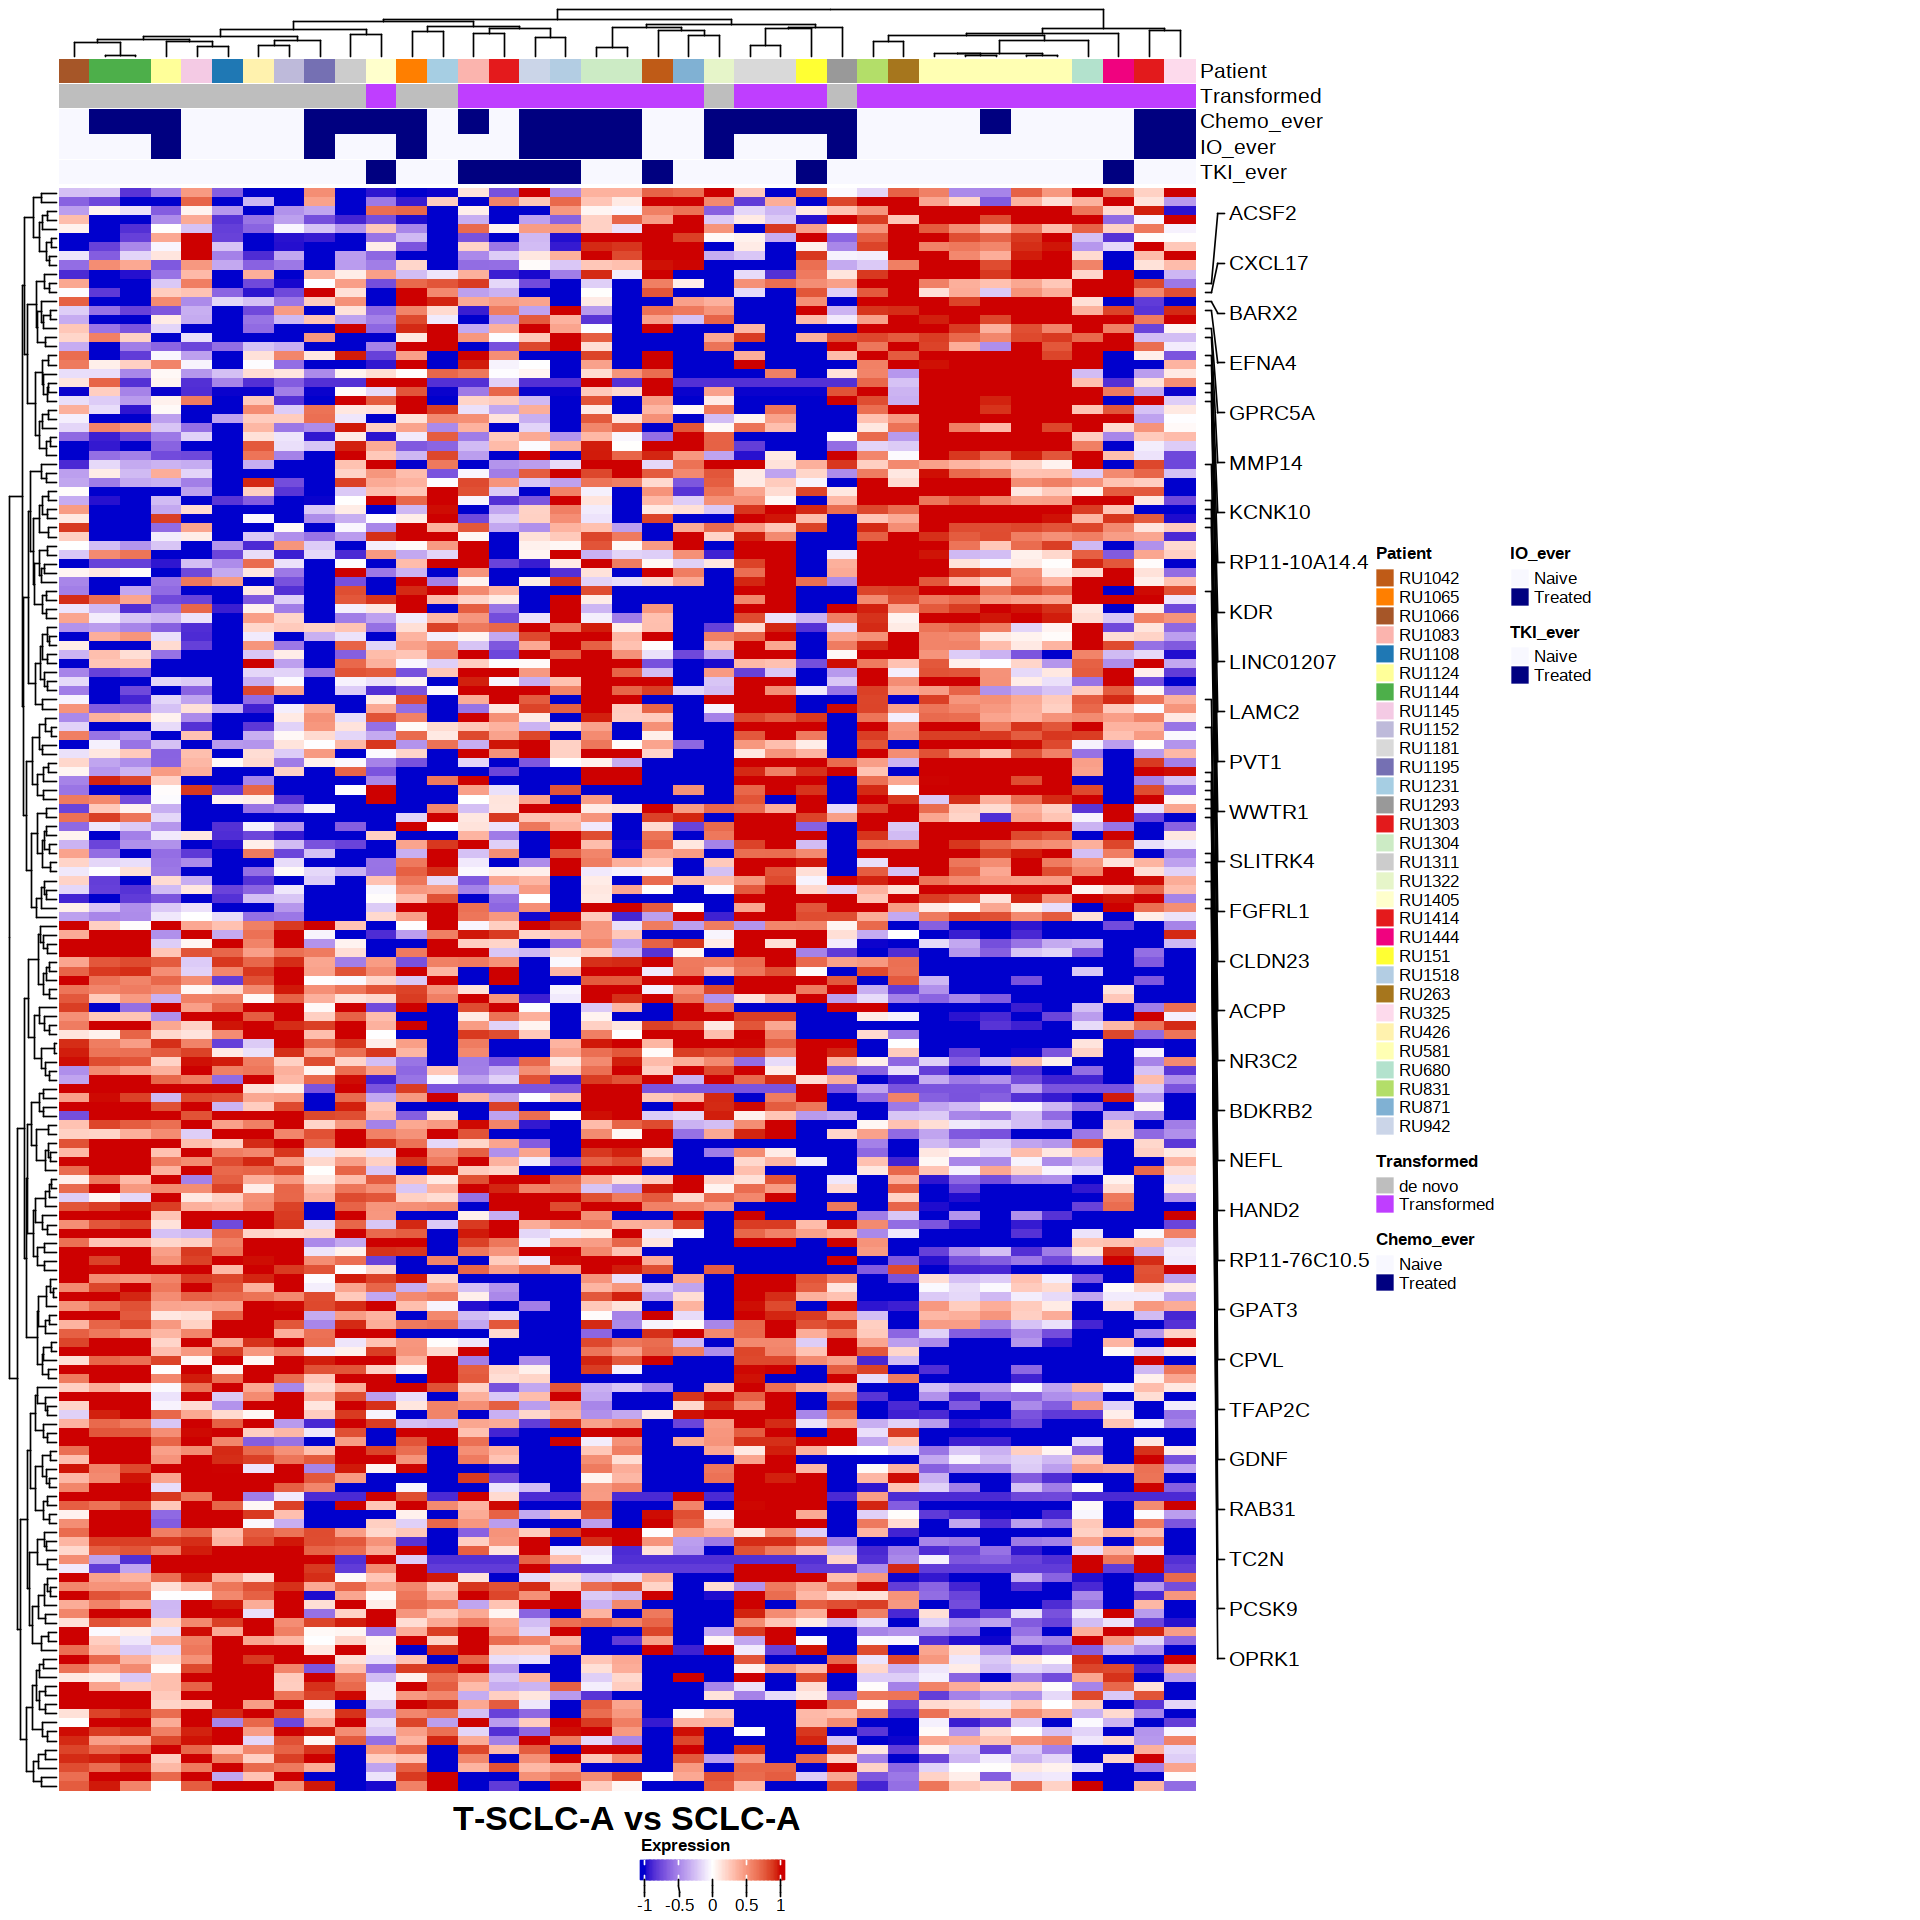

In [1344]:
ha = HeatmapAnnotation(df = df2, 
                   col = col_list,
                   annotation_width=0.1)

hm = Heatmap(scaled_df, name = "Expression", 
    col = colorRamp2(c(-1, 0, 1), c('blue3','white','red3')),
    top_annotation = ha, cluster_columns = T, # column_dend_l, 
    cluster_rows = T, 
    clustering_distance_rows = "pearson", 
    clustering_distance_columns = "pearson",
    #column_split = df2$Subtype, #c('Luminal genes', 'Basal genes')[(rownames(hm_mat) %in% c(b_up, b_dn))+1],
    show_row_names = T, 
    show_column_names = F, column_title = 'T-SCLC-A vs SCLC-A', column_title_side = "bottom", row_title_rot = 90,
    row_title_gp = gpar(fontsize=13, fontface = "bold"),column_title_gp = gpar(fontsize=20, fontface = "bold", rot = 90), 
    heatmap_legend_param = list(direction = 'horizontal')) +
# Heatmap(BL_annot[BL_annot!='_'], name = ' ', col = c("_" = 'white', "Luminal" = 'blue4'," LIF"='brown', "JAK/STAT"="salmon","Basal"='red4',"Androgen"='turquoise',"EMT"='lightgreen',"FGFR"='purple',"IFN"='orange'), 
#     show_row_names = T, show_heatmap_legend = T, width = unit(5, "mm"))  #+
rowAnnotation(link = anno_mark(at = which(rownames(scaled_df) %in% le_genes_all), 
    labels = rownames(scaled_df)[rownames(scaled_df) %in% le_genes_all], 
    labels_gp = gpar(fontsize = 12), padding = unit(.0001, "mm")))

draw(hm, padding = unit(c(2, 2, 2, 70), "mm"), heatmap_legend_side = "bottom")
